Running Pandas Test (Eager Evaluation)...
   Forcing OS to drop file caches via memory pressure...
   OS Cache cleared. Test environment is cold and clean.
[Pandas] Execution failed (OOM/Error): malloc of size 4294967296 failed

Running Polars Test (Lazy Evaluation)...
   Forcing OS to drop file caches via memory pressure...
   OS Cache cleared. Test environment is cold and clean.
   Calibrating background disk I/O noise for Polars...
[Polars] Completed! Time: 1.10s | Peak Mem: 1276.32 MB | True Disk Read: 378.72 MB

Running Dask Test (Task Graphs)...
   Forcing OS to drop file caches via memory pressure...
   OS Cache cleared. Test environment is cold and clean.
[Dask] Completed! Time: 6.17s | Peak Mem: 0.18 MB | True Disk Read: 516.81 MB

Generating visual comparison charts...


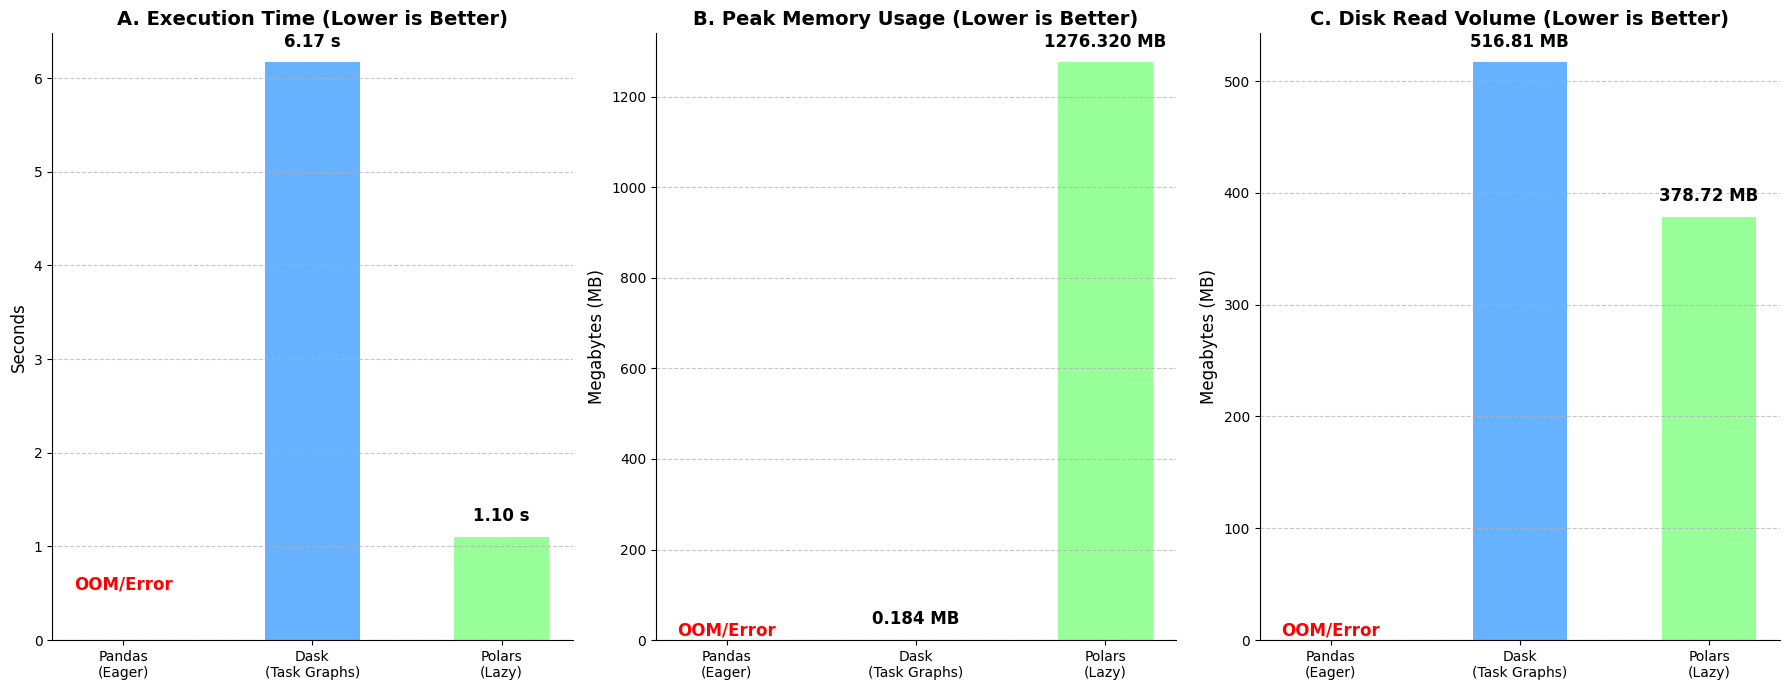

Benchmarking finished!


In [1]:
import pandas as pd
import polars as pl
import dask.dataframe as dd
import time
import matplotlib.pyplot as plt
import psutil
import os
import threading
import gc

# ==========================================
# 0. Configuration & Memory Tracker setup
# ==========================================
FILE_PATH = "dataset/yearly collections/2009.parquet" 

# ==========================================
# 0.5 Dynamic Column Discovery (Handle Schema Drift)
# ==========================================
#print("Sniffing schema to handle column name drifts...")
# Use Polars to instantly read just the metadata (0 memory cost)
file_columns = pl.scan_parquet(FILE_PATH).collect_schema().names()

# Initialize dynamic variables
PASSENGER_COL = None
FARE_COL = None

# Smart string matching to find the exact column names used in THIS file
for col in file_columns:
    col_lower = col.lower()
    if "passenger" in col_lower and "count" in col_lower:
        PASSENGER_COL = col
    elif "fare" in col_lower and ("amount" in col_lower or "amt" in col_lower):
        FARE_COL = col

if not PASSENGER_COL or not FARE_COL:
    raise ValueError(f"CRITICAL: Could not detect target columns in {FILE_PATH}. Available columns: {file_columns}")

#print(f"Auto-detected Columns -> Passenger: '{PASSENGER_COL}', Fare: '{FARE_COL}'\n")

# Dictionary to store results: { 'Framework': {'time': seconds, 'memory': MB, 'disk': MB} }
benchmark_results = {}

# ==========================================
# Background thread class to track TRUE peak memory usage
# (PRO Upgraded for Multi-Process / Distributed Architectures)
# ==========================================
class MemoryTracker:
    def __init__(self):
        self.keep_measuring = True
        self.peak_memory = 0

    def track(self):
        main_process = psutil.Process(os.getpid())
        
        while self.keep_measuring:
            try:
                # 1. Capture the memory of the main process 
                # (For Dask, this is just the lightweight Scheduler)
                total_mem_bytes = main_process.memory_info().rss
                
                # 2. Recursively capture memory from all child processes
                # (This is the core logic to overcome the Dask telemetry blindspot,
                # ensuring we capture the actual Worker nodes carrying the data payload)
                for child in main_process.children(recursive=True):
                    try:
                        total_mem_bytes += child.memory_info().rss
                    except (psutil.NoSuchProcess, psutil.AccessDenied):
                        # Prevent crashes if a worker process is terminated 
                        # exactly during the polling instant
                        pass
                
                # Convert total bytes to Megabytes (MB)
                current_mem_mb = total_mem_bytes / (1024 * 1024)
                
                # Update the peak memory recorded
                if current_mem_mb > self.peak_memory:
                    self.peak_memory = current_mem_mb
                    
            except Exception:
                # Ultimate fallback to prevent the background monitoring thread 
                # from crashing and halting the main benchmark
                pass 
                
            time.sleep(0.05) # Poll every 50ms for high precision

def clear_os_cache():
    """
    Advanced workaround: Forces the Windows operating system to evict file caches 
    (from the Standby List) by momentarily allocating a massive amount of memory. 
    This guarantees an absolutely fair "Cold Cache" baseline for every framework tested.
    """
    print("   Forcing OS to drop file caches via memory pressure...")
    mem = psutil.virtual_memory()
    
    try:
        # Calculate 80% of the currently available system memory
        target_bytes = int(mem.available * 0.8)
        
        # Generate a massive byte string to force the OS to allocate real physical memory,
        # which pushes out cached files to make room.
        _dummy_data = b'0' * target_bytes
        
        # Instantly delete the dummy data to free the memory back to the system
        del _dummy_data
    except MemoryError:
        # If we hit a MemoryError, it means we pushed the memory to its absolute limit, 
        # which virtually guarantees the OS caches are wiped.
        pass
    
    # Run Python's garbage collector and let the system settle
    gc.collect()
    time.sleep(2)
    print("   OS Cache cleared. Test environment is cold and clean.")

def run_with_tracker(func, framework_name):
    """
    Helper function to run the test and track memory & TRUE disk I/O simultaneously.
    Implements Early Branching for Telemetry: Instantiates only the required I/O 
    sensors based on the framework, avoiding redundant system calls and unnecessary 
    calibration sleep times.
    """
    clear_os_cache()
    
    process = psutil.Process(os.getpid())
    baseline_mem = process.memory_info().rss / (1024 * 1024)
    
    # ---------------------------------------------------------
    # EARLY BRANCHING: Setup only the specific telemetry needed
    # ---------------------------------------------------------
    is_polars = (framework_name == "Polars")
    
    if is_polars:
        # Polars relies on mmap, requiring system-wide monitoring and noise calibration
        print("   Calibrating background disk I/O noise for Polars...")
        bg_io_start = psutil.disk_io_counters().read_bytes
        time.sleep(1) 
        bg_io_rate = psutil.disk_io_counters().read_bytes - bg_io_start 
        
        # Base system I/O
        base_io = psutil.disk_io_counters().read_bytes
    else:
        # Pandas/Dask rely on standard syscalls, requiring only process-level monitoring (no sleep needed)
        try:
            base_io = process.io_counters().read_bytes
        except AttributeError:
            base_io = 0
            
    # Start memory tracker thread
    tracker = MemoryTracker()
    tracker_thread = threading.Thread(target=tracker.track)
    tracker_thread.start()

    start_time = time.time()
    success = False
    
    try:
        func() 
        success = True
    except Exception as e:
        print(f"[{framework_name}] Execution failed (OOM/Error): {e}\n")
    finally:
        end_time = time.time()
        
        # ---------------------------------------------------------
        # EARLY BRANCHING: Collect from the specific telemetry used
        # ---------------------------------------------------------
        if is_polars:
            end_io = psutil.disk_io_counters().read_bytes
        else:
            try:
                end_io = process.io_counters().read_bytes
            except AttributeError:
                end_io = 0
                
        # Stop tracker
        tracker.keep_measuring = False
        tracker_thread.join()

    # Calculate final metrics
    elapsed_time = end_time - start_time if success else 0
    net_peak_memory = max(0, tracker.peak_memory - baseline_mem)
    
    if success:
        if is_polars:
            # Apply noise cancellation for Polars
            estimated_bg_noise = bg_io_rate * elapsed_time
            final_disk_bytes = max(0, (end_io - base_io) - estimated_bg_noise)
        else:
            # Exact process-level delta for Pandas/Dask
            final_disk_bytes = max(0, end_io - base_io)
            
        net_disk_mb = final_disk_bytes / (1024 * 1024)
    else:
        net_disk_mb = 0
    
    # Store results
    benchmark_results[framework_name] = {
        'time': elapsed_time,
        'memory': net_peak_memory if success else 0,
        'disk': net_disk_mb
    }
    
    if success:
        print(f"[{framework_name}] Completed! Time: {elapsed_time:.2f}s | Peak Mem: {net_peak_memory:.2f} MB | True Disk Read: {net_disk_mb:.2f} MB\n")

# ==========================================
# 1. Define Test Functions (Fully Dynamic Now)
# ==========================================
def test_pandas():
    df = pd.read_parquet(FILE_PATH, engine='pyarrow')
    df_filtered = df[df[PASSENGER_COL] > 1]
    df_grouped = df_filtered.groupby(PASSENGER_COL)[FARE_COL].mean()

def test_polars():
    lazy_df = pl.scan_parquet(FILE_PATH)
    lazy_filtered = lazy_df.filter(pl.col(PASSENGER_COL) > 1)
    lazy_grouped = lazy_filtered.group_by(PASSENGER_COL).agg(
        pl.col(FARE_COL).mean().alias('avg_fare')
    )
    result = lazy_grouped.collect()

def test_dask():
    ddf = dd.read_parquet(FILE_PATH, engine='pyarrow')
    ddf_filtered = ddf[ddf[PASSENGER_COL] > 1]
    ddf_grouped = ddf_filtered.groupby(PASSENGER_COL)[FARE_COL].mean()
    result = ddf_grouped.compute()

# ==========================================
# 2. Run Benchmarks
# ==========================================
print("Running Pandas Test (Eager Evaluation)...")
run_with_tracker(test_pandas, "Pandas")

print("Running Polars Test (Lazy Evaluation)...")
run_with_tracker(test_polars, "Polars")

print("Running Dask Test (Task Graphs)...")
run_with_tracker(test_dask, "Dask")

# ==========================================
# 3. Generate Side-by-Side Comparison Charts
# ==========================================
print("Generating visual comparison charts...")

frameworks = ['Pandas\n(Eager)', 'Dask\n(Task Graphs)', 'Polars\n(Lazy)']
times = [benchmark_results.get('Pandas', {}).get('time', 0), 
         benchmark_results.get('Dask', {}).get('time', 0), 
         benchmark_results.get('Polars', {}).get('time', 0)]
memories = [benchmark_results.get('Pandas', {}).get('memory', 0), 
            benchmark_results.get('Dask', {}).get('memory', 0), 
            benchmark_results.get('Polars', {}).get('memory', 0)]
disks = [benchmark_results.get('Pandas', {}).get('disk', 0), 
         benchmark_results.get('Dask', {}).get('disk', 0), 
         benchmark_results.get('Polars', {}).get('disk', 0)]

# Create a figure with 1 row and 3 columns (Widened figsize for 3 charts)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 7))
colors = ['#FF9999', '#66B2FF', '#99FF99']

# --- Subplot 1: Execution Time ---
bars1 = ax1.bar(frameworks, times, color=colors, width=0.5)
ax1.set_title('A. Execution Time (Lower is Better)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Seconds', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for bar in bars1:
    yval = bar.get_height()
    if yval > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, yval + (max(times)*0.02), 
                 f"{yval:.2f} s", ha='center', va='bottom', fontsize=12, fontweight='bold')
    else:
        ax1.text(bar.get_x() + bar.get_width()/2, 0.5, "OOM/Error", ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

# --- Subplot 2: Peak Memory Usage ---
bars2 = ax2.bar(frameworks, memories, color=colors, width=0.5)
ax2.set_title('B. Peak Memory Usage (Lower is Better)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Megabytes (MB)', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for bar in bars2:
    yval = bar.get_height()
    if yval > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, yval + (max(memories)*0.02), 
                 f"{yval:.3f} MB", ha='center', va='bottom', fontsize=12, fontweight='bold')
    else:
        ax2.text(bar.get_x() + bar.get_width()/2, 0.5, "OOM/Error", ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

# --- Subplot 3: Disk Read Volume ---
bars3 = ax3.bar(frameworks, disks, color=colors, width=0.5)
ax3.set_title('C. Disk Read Volume (Lower is Better)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Megabytes (MB)', fontsize=12)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

for i, bar in enumerate(bars3):
    yval = bar.get_height()
    if yval > 0 or times[i] > 0:
        offset = max(disks)*0.02 if max(disks) > 0 else 0.5 
        ax3.text(bar.get_x() + bar.get_width()/2, yval + offset, 
                 f"{yval:.2f} MB", ha='center', va='bottom', fontsize=12, fontweight='bold')
    else:
        ax3.text(bar.get_x() + bar.get_width()/2, 0.5, "OOM/Error", ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')
plt.tight_layout()
plt.show() # Automatically displays the chart in Jupyter
print(f"Benchmarking finished!")

Sniffing schema in main process...
Starting Fully Isolated Benchmark Suite...

All isolated tests finished! Generating visual comparison charts...


C:\Users\Floyd\AppData\Local\Temp\ipykernel_2292\2449258041.py:296: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


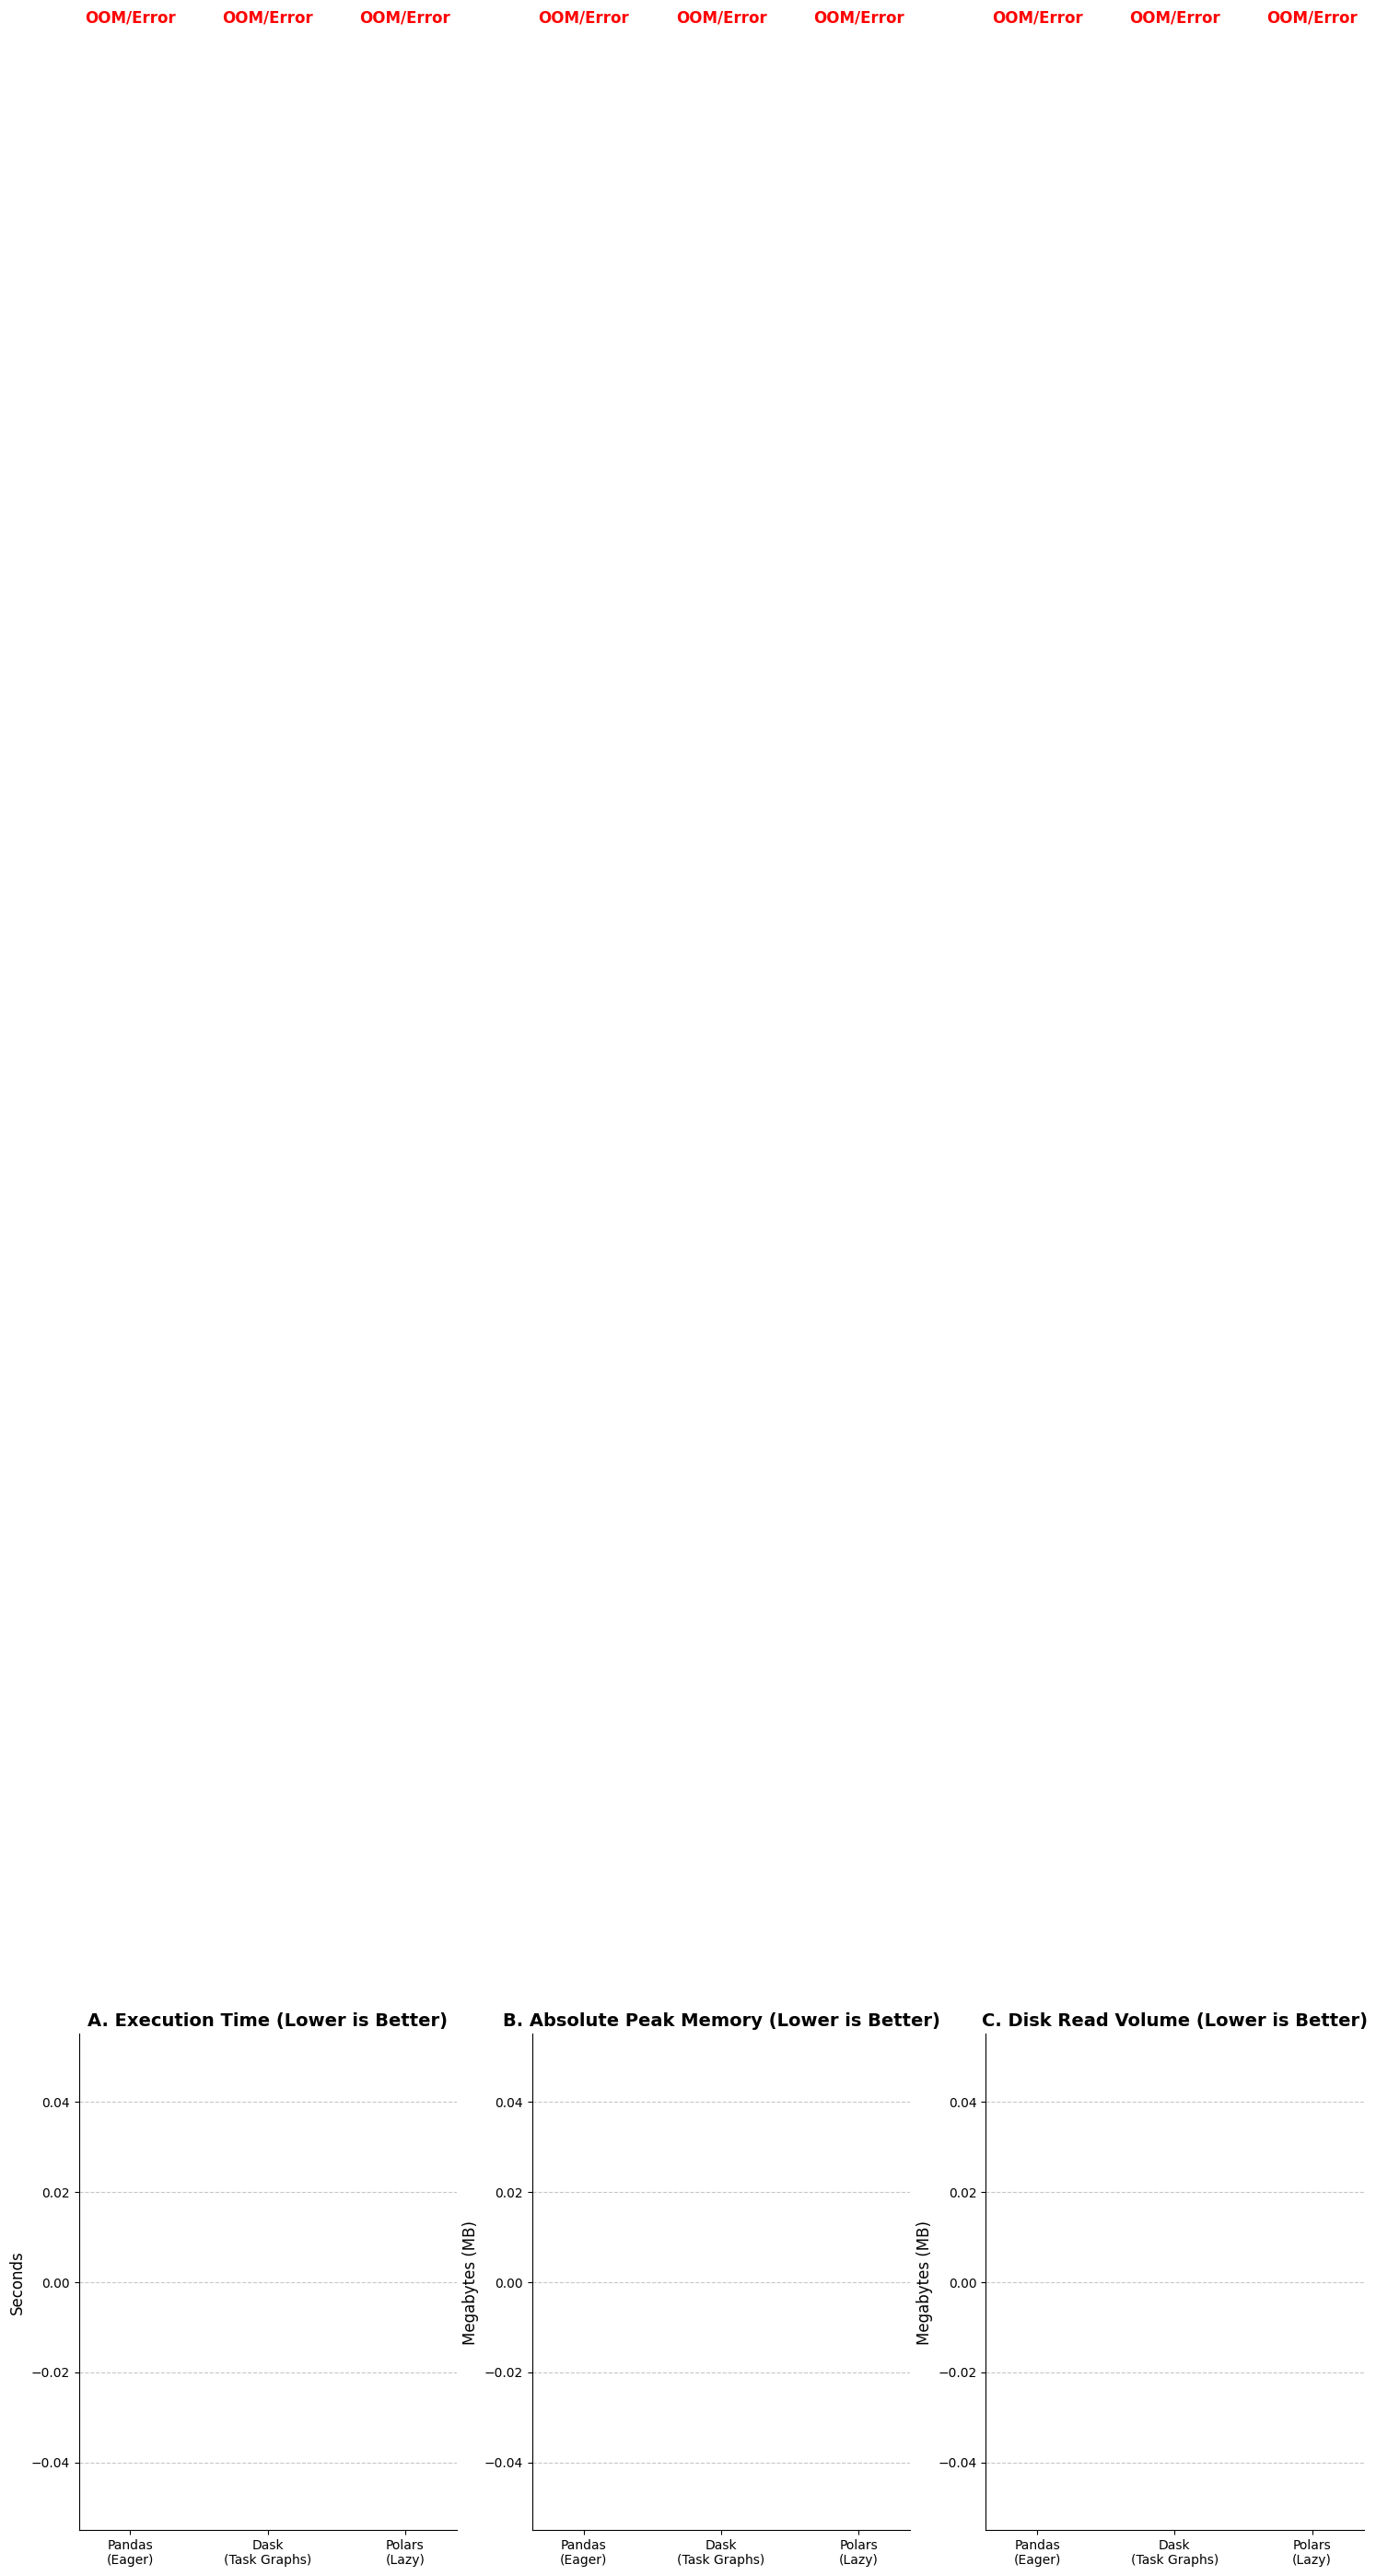

Benchmarking suite execution finalized successfully!


In [ ]:
import pandas as pd
import polars as pl
import dask.dataframe as dd
import time
import matplotlib.pyplot as plt
import psutil
import os
import threading
import gc
import multiprocessing as mp

# ==========================================
# 0. Configuration
# ==========================================
FILE_PATH = "dataset/yearly collections/2009.parquet" 

# Global variables to be injected into child processes
PASSENGER_COL = None
FARE_COL = None

# ==========================================
# Background thread class to track TRUE peak memory usage
# ==========================================
class MemoryTracker:
    def __init__(self):
        self.keep_measuring = True
        self.peak_memory = 0

    def track(self):
        main_process = psutil.Process(os.getpid())
        
        while self.keep_measuring:
            try:
                total_mem_bytes = main_process.memory_info().rss
                
                # Recursively capture memory from all child processes
                for child in main_process.children(recursive=True):
                    try:
                        total_mem_bytes += child.memory_info().rss
                    except (psutil.NoSuchProcess, psutil.AccessDenied):
                        pass
                
                current_mem_mb = total_mem_bytes / (1024 * 1024)
                
                if current_mem_mb > self.peak_memory:
                    self.peak_memory = current_mem_mb
                    
            except Exception:
                pass 
                
            time.sleep(0.05) 

# ==========================================
# Core Benchmarking Functions
# ==========================================
def clear_os_cache():
    print("   Forcing OS to drop file caches via memory pressure...")
    mem = psutil.virtual_memory()
    try:
        # Reduce to 60% to avoid instant OS-level OOM kills on 5GB data machines
        target_bytes = int(mem.available * 0.6)
        _dummy_data = b'0' * target_bytes
        del _dummy_data
    except MemoryError:
        pass
    gc.collect()
    time.sleep(2)

def run_with_tracker(func, framework_name):
    clear_os_cache()
    process = psutil.Process(os.getpid())
    
    is_polars = (framework_name == "Polars")
    
    if is_polars:
        print("   Calibrating background disk I/O noise for Polars...")
        bg_io_start = psutil.disk_io_counters().read_bytes
        time.sleep(1) 
        bg_io_rate = psutil.disk_io_counters().read_bytes - bg_io_start 
        base_io = psutil.disk_io_counters().read_bytes
    else:
        try:
            base_io = process.io_counters().read_bytes
        except AttributeError:
            base_io = 0
            
    tracker = MemoryTracker()
    tracker_thread = threading.Thread(target=tracker.track)
    tracker_thread.start()

    start_time = time.time()
    success = False
    
    try:
        func() 
        success = True
    except Exception as e:
        print(f"[{framework_name}] Execution failed (OOM/Error): {e}\n")
    finally:
        end_time = time.time()
        
        if is_polars:
            end_io = psutil.disk_io_counters().read_bytes
        else:
            try:
                end_io = process.io_counters().read_bytes
            except AttributeError:
                end_io = 0
                
        tracker.keep_measuring = False
        tracker_thread.join()

    elapsed_time = end_time - start_time if success else 0
    absolute_peak_memory = tracker.peak_memory if success else 0
    
    if success:
        if is_polars:
            estimated_bg_noise = bg_io_rate * elapsed_time
            final_disk_bytes = max(0, (end_io - base_io) - estimated_bg_noise)
        else:
            final_disk_bytes = max(0, end_io - base_io)
        net_disk_mb = final_disk_bytes / (1024 * 1024)
    else:
        net_disk_mb = 0
    
    result_dict = {
        'time': elapsed_time,
        'memory': absolute_peak_memory,
        'disk': net_disk_mb,
        'success': success
    }
    
    if success:
        print(f"[{framework_name}] Completed! Time: {elapsed_time:.2f}s | Absolute Peak Mem: {absolute_peak_memory:.2f} MB")
        
    return result_dict

def isolated_worker(framework_name, func, queue, pass_col, fare_col):
    """
    Sterile subprocess. Global variables are injected safely here.
    """
    global PASSENGER_COL, FARE_COL
    PASSENGER_COL = pass_col
    FARE_COL = fare_col
    
    print(f"\n--- Spawning isolated OS subprocess for {framework_name} ---")
    try:
        result = run_with_tracker(func, framework_name)
        queue.put((framework_name, result))
    except Exception as e:
        print(f"[{framework_name}] Critical failure in isolated process: {e}")
        queue.put((framework_name, {'time': 0, 'memory': 0, 'disk': 0, 'success': False}))

# ==========================================
# 1. Define Test Functions
# ==========================================
def test_pandas():
    df = pd.read_parquet(FILE_PATH, engine='pyarrow')
    df_filtered = df[df[PASSENGER_COL] > 1]
    df_grouped = df_filtered.groupby(PASSENGER_COL)[FARE_COL].mean()

def test_polars():
    lazy_df = pl.scan_parquet(FILE_PATH)
    lazy_filtered = lazy_df.filter(pl.col(PASSENGER_COL) > 1)
    lazy_grouped = lazy_filtered.group_by(PASSENGER_COL).agg(
        pl.col(FARE_COL).mean().alias('avg_fare')
    )
    result = lazy_grouped.collect()

def test_dask():
    ddf = dd.read_parquet(FILE_PATH, engine='pyarrow')
    ddf_filtered = ddf[ddf[PASSENGER_COL] > 1]
    ddf_grouped = ddf_filtered.groupby(PASSENGER_COL)[FARE_COL].mean()
    result = ddf_grouped.compute()

# ==========================================
# 2. Main Execution Block (Process Isolation Engine)
# ==========================================
if __name__ == '__main__':
    mp.freeze_support() 
    
    print("Sniffing schema in main process...")
    # SAFE ZONE: Extract schema only once in the main process
    file_columns = pl.scan_parquet(FILE_PATH).collect_schema().names()
    
    detect_passenger, detect_fare = None, None
    for col in file_columns:
        col_lower = col.lower()
        if "passenger" in col_lower and "count" in col_lower:
            detect_passenger = col
        elif "fare" in col_lower and ("amount" in col_lower or "amt" in col_lower):
            detect_fare = col

    if not detect_passenger or not detect_fare:
        raise ValueError(f"CRITICAL: Could not detect target columns.")
        
    print("Starting Fully Isolated Benchmark Suite...")
    
    result_queue = mp.Queue()
    benchmark_results = {}
    
    tasks = [
        ("Pandas", test_pandas),
        ("Polars", test_polars),
        ("Dask", test_dask)
    ]
    
    for name, func in tasks:
        p = mp.Process(target=isolated_worker, args=(name, func, result_queue, detect_passenger, detect_fare))
        p.start()
        
        # BULLETPROOF IPC RETRIEVAL: Wait until process puts data or dies
        metrics = {'time': 0, 'memory': 0, 'disk': 0, 'success': False}
        while p.is_alive():
            if not result_queue.empty():
                returned_name, metrics = result_queue.get()
                break
            time.sleep(0.1)
            
        p.join() # Wait for OS to clean up the process completely
        
        # One final check in case the queue flushed exactly as the process died
        if not result_queue.empty():
            returned_name, metrics = result_queue.get()
            
        benchmark_results[name] = metrics

    # ==========================================
    # 3. Generate Side-by-Side Comparison Charts
    # ==========================================
    print("\nAll isolated tests finished! Generating visual comparison charts...")

    frameworks = ['Pandas\n(Eager)', 'Dask\n(Task Graphs)', 'Polars\n(Lazy)']
    times = [benchmark_results.get('Pandas', {}).get('time', 0), 
             benchmark_results.get('Dask', {}).get('time', 0), 
             benchmark_results.get('Polars', {}).get('time', 0)]
    memories = [benchmark_results.get('Pandas', {}).get('memory', 0), 
                benchmark_results.get('Dask', {}).get('memory', 0), 
                benchmark_results.get('Polars', {}).get('memory', 0)]
    disks = [benchmark_results.get('Pandas', {}).get('disk', 0), 
             benchmark_results.get('Dask', {}).get('disk', 0), 
             benchmark_results.get('Polars', {}).get('disk', 0)]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 7))
    colors = ['#FF9999', '#66B2FF', '#99FF99']

    # --- Subplot 1: Execution Time ---
    bars1 = ax1.bar(frameworks, times, color=colors, width=0.5)
    ax1.set_title('A. Execution Time (Lower is Better)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Seconds', fontsize=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    for bar in bars1:
        yval = bar.get_height()
        if yval > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, yval + (max(times)*0.02), 
                     f"{yval:.2f} s", ha='center', va='bottom', fontsize=12, fontweight='bold')
        else:
            ax1.text(bar.get_x() + bar.get_width()/2, 0.5, "OOM/Error", ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

    # --- Subplot 2: Peak Memory Usage ---
    bars2 = ax2.bar(frameworks, memories, color=colors, width=0.5)
    ax2.set_title('B. Absolute Peak Memory (Lower is Better)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Megabytes (MB)', fontsize=12)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    for bar in bars2:
        yval = bar.get_height()
        if yval > 0:
            ax2.text(bar.get_x() + bar.get_width()/2, yval + (max(memories)*0.02), 
                     f"{yval:.1f} MB", ha='center', va='bottom', fontsize=12, fontweight='bold')
        else:
            ax2.text(bar.get_x() + bar.get_width()/2, 0.5, "OOM/Error", ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

    # --- Subplot 3: Disk Read Volume ---
    bars3 = ax3.bar(frameworks, disks, color=colors, width=0.5)
    ax3.set_title('C. Disk Read Volume (Lower is Better)', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Megabytes (MB)', fontsize=12)
    ax3.grid(axis='y', linestyle='--', alpha=0.7)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    for i, bar in enumerate(bars3):
        yval = bar.get_height()
        if yval > 0 or times[i] > 0:
            offset = max(disks)*0.02 if max(disks) > 0 else 0.5 
            ax3.text(bar.get_x() + bar.get_width()/2, yval + offset, 
                     f"{yval:.2f} MB", ha='center', va='bottom', fontsize=12, fontweight='bold')
        else:
            ax3.text(bar.get_x() + bar.get_width()/2, 0.5, "OOM/Error", ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')
            
    plt.tight_layout()
    plt.show() 
    print("Benchmarking suite execution finalized successfully!")